In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# 设置中文显示（必加，避免乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

In [3]:
file_path = r'plot_scatter.csv'

df = pd.read_csv(
    file_path,
    encoding='utf-8'
)

df

,商品ID,单价(元),销量,利润(元),成本(元),品类
0,1001,2999,20,598,2401,手机
1,1002,2999,25,748,2251,手机
2,1003,2999,18,448,2551,手机
3,1004,1999,30,398,1601,耳机
4,1005,1999,22,348,1651,耳机
5,1006,1999,19,298,1701,耳机
6,1007,199,28,38,161,卫衣
7,1008,199,35,58,141,卫衣
8,1009,199,40,78,121,卫衣
9,1010,199,15,28,171,卫衣


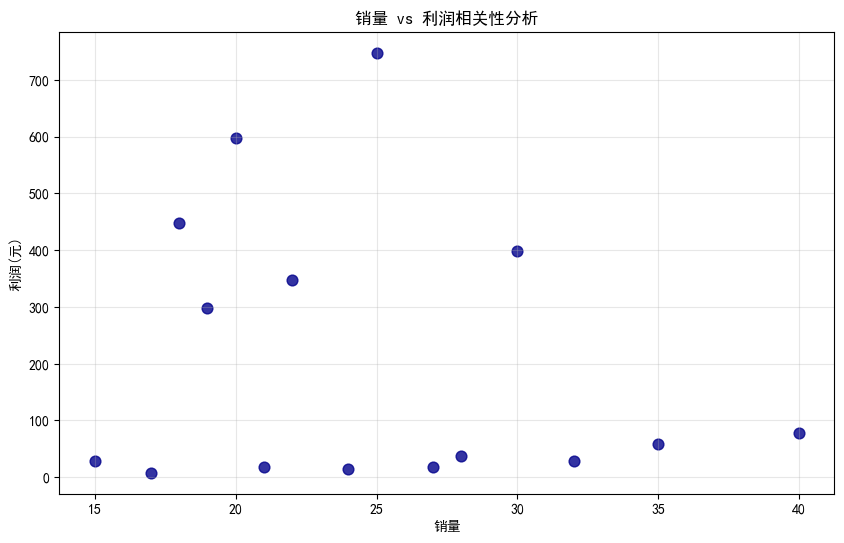

In [4]:
df.plot(
    kind='scatter',      # 指定散点图类型
    x='销量',             # x轴：销量
    y='利润(元)',         # y轴：利润
    figsize=(10, 6),     # 图大小
    title='销量 vs 利润相关性分析',
    color='darkblue',    # 点颜色
    s=60,                # 点大小（size）
    alpha=0.8            # 透明度
)
plt.grid(True, alpha=0.3)
plt.show()

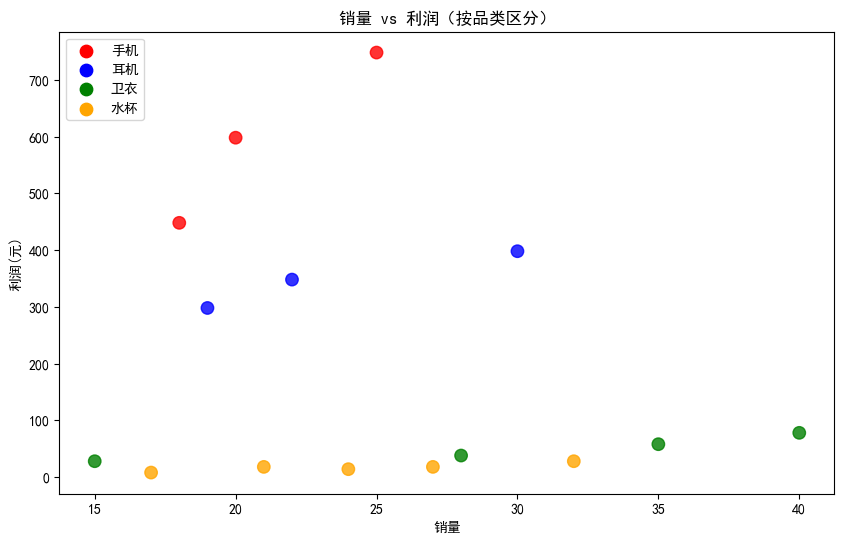

In [7]:
color_map = {'手机':'red', '耳机':'blue', '卫衣':'green', '水杯':'orange'}

df.plot(
    kind='scatter',
    x='销量',
    y='利润(元)',
    figsize=(10, 6),
    title='销量 vs 利润（按品类区分）',
    c=df['品类'].map(color_map),  # 按品类赋值颜色
    s=80,
    alpha=0.8
)

for category, color in color_map.items():
    plt.scatter([], [], c=color, label=category, s=80)

plt.legend(loc='upper left')
plt.show()

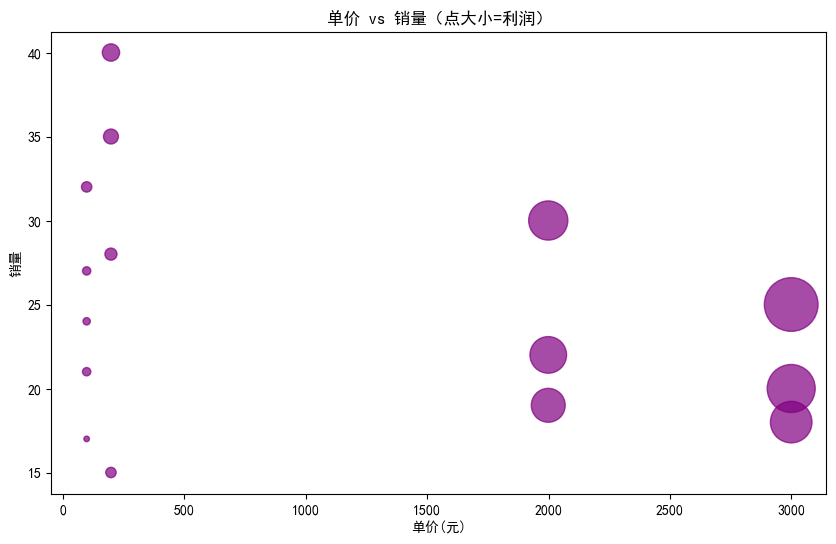

In [8]:
df.plot(
    kind='scatter',
    x='单价(元)',
    y='销量',
    figsize=(10, 6),
    title='单价 vs 销量（点大小=利润）',
    c='purple',
    s=df['利润(元)']*2,  # 利润值放大2倍作为点大小
    alpha=0.7)
plt.show()

In [9]:
import numpy as np
from scipy import stats

In [14]:
df

,商品ID,单价(元),销量,利润(元),成本(元),品类
0,1001,2999,20,598,2401,手机
1,1002,2999,25,748,2251,手机
2,1003,2999,18,448,2551,手机
3,1004,1999,30,398,1601,耳机
4,1005,1999,22,348,1651,耳机
5,1006,1999,19,298,1701,耳机
6,1007,199,28,38,161,卫衣
7,1008,199,35,58,141,卫衣
8,1009,199,40,78,121,卫衣
9,1010,199,15,28,171,卫衣


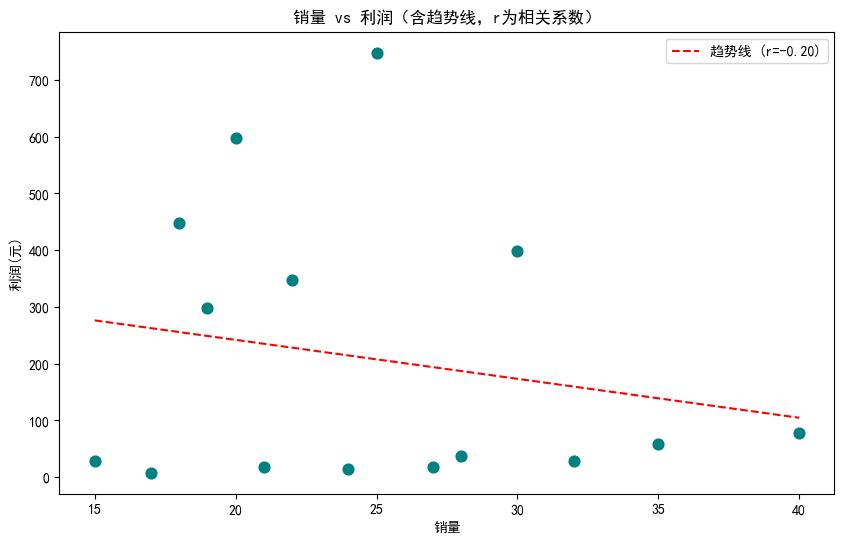

In [13]:
ax = df.plot(kind='scatter', x='销量', y='利润(元)', figsize=(10,6), color='teal', s=60)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['销量'], df['利润(元)'])

x_trend = np.linspace(df['销量'].min(), df['销量'].max(), 100)
y_trend = intercept + slope * x_trend

ax.plot(x_trend, y_trend, 'r--', label=f'趋势线 (r={r_value:.2f})')
ax.legend()

plt.title('销量 vs 利润（含趋势线，r为相关系数）')
plt.show()

In [15]:
df

,商品ID,单价(元),销量,利润(元),成本(元),品类
0,1001,2999,20,598,2401,手机
1,1002,2999,25,748,2251,手机
2,1003,2999,18,448,2551,手机
3,1004,1999,30,398,1601,耳机
4,1005,1999,22,348,1651,耳机
5,1006,1999,19,298,1701,耳机
6,1007,199,28,38,161,卫衣
7,1008,199,35,58,141,卫衣
8,1009,199,40,78,121,卫衣
9,1010,199,15,28,171,卫衣


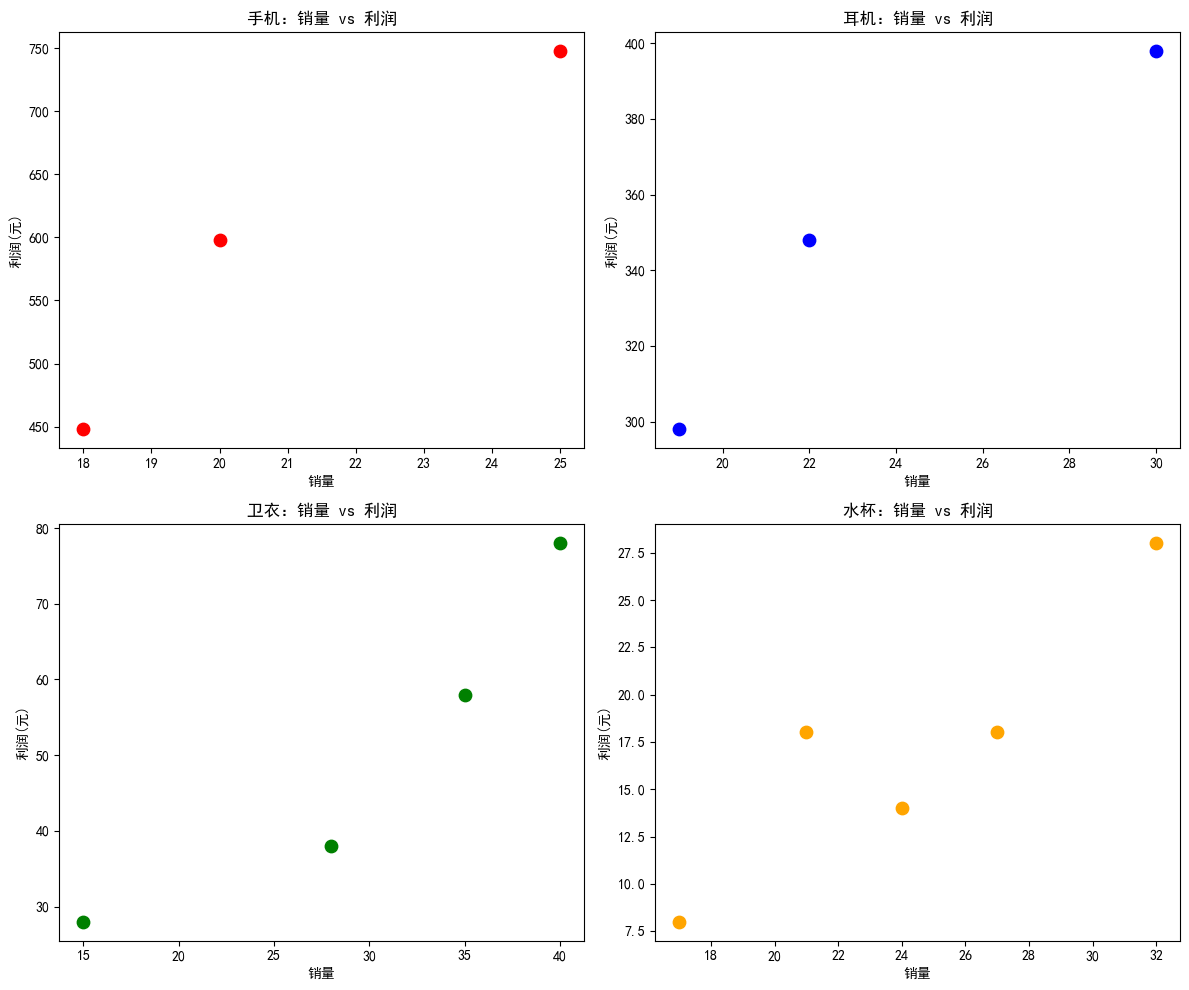

In [17]:
import matplotlib.pyplot as plt

# 你的原有代码（仅修改 axes 取值方式）
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# 关键：把二维 axes 展平为一维数组，方便循环索引
axes = axes.flatten()

categories = ['手机', '耳机', '卫衣', '水杯']
# 假设你已经定义了 color_map 字典
# color_map = {'手机':'red', '耳机':'blue', '卫衣':'green', '水杯':'orange'}

for i, cat in enumerate(categories):
    df_cat = df[df['品类'] == cat]
    df_cat.plot(
        kind='scatter',
        x='销量',
        y='利润(元)',
        ax=axes[i],  # 现在 axes[i] 是单个子图，正常使用
        title=f'{cat}：销量 vs 利润',
        color=color_map[cat],
        s=80)
plt.tight_layout()
plt.show()

In [18]:
df

,商品ID,单价(元),销量,利润(元),成本(元),品类
0,1001,2999,20,598,2401,手机
1,1002,2999,25,748,2251,手机
2,1003,2999,18,448,2551,手机
3,1004,1999,30,398,1601,耳机
4,1005,1999,22,348,1651,耳机
5,1006,1999,19,298,1701,耳机
6,1007,199,28,38,161,卫衣
7,1008,199,35,58,141,卫衣
8,1009,199,40,78,121,卫衣
9,1010,199,15,28,171,卫衣


In [20]:
df_filtered = df[(df['利润(元)'] > 0) & (df['销量'] < 45)]

df_filtered

,商品ID,单价(元),销量,利润(元),成本(元),品类
0,1001,2999,20,598,2401,手机
1,1002,2999,25,748,2251,手机
2,1003,2999,18,448,2551,手机
3,1004,1999,30,398,1601,耳机
4,1005,1999,22,348,1651,耳机
5,1006,1999,19,298,1701,耳机
6,1007,199,28,38,161,卫衣
7,1008,199,35,58,141,卫衣
8,1009,199,40,78,121,卫衣
9,1010,199,15,28,171,卫衣


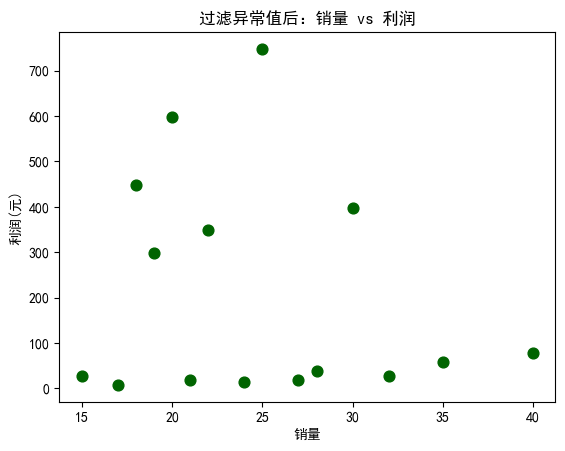

In [21]:
df_filtered.plot(
    kind='scatter',
    x='销量',
    y='利润(元)',
    title='过滤异常值后：销量 vs 利润',
    color='darkgreen',
    s=60)
plt.show()

In [22]:
df

,商品ID,单价(元),销量,利润(元),成本(元),品类
0,1001,2999,20,598,2401,手机
1,1002,2999,25,748,2251,手机
2,1003,2999,18,448,2551,手机
3,1004,1999,30,398,1601,耳机
4,1005,1999,22,348,1651,耳机
5,1006,1999,19,298,1701,耳机
6,1007,199,28,38,161,卫衣
7,1008,199,35,58,141,卫衣
8,1009,199,40,78,121,卫衣
9,1010,199,15,28,171,卫衣


In [23]:
df_null = df.copy()
df_null

,商品ID,单价(元),销量,利润(元),成本(元),品类
0,1001,2999,20,598,2401,手机
1,1002,2999,25,748,2251,手机
2,1003,2999,18,448,2551,手机
3,1004,1999,30,398,1601,耳机
4,1005,1999,22,348,1651,耳机
5,1006,1999,19,298,1701,耳机
6,1007,199,28,38,161,卫衣
7,1008,199,35,58,141,卫衣
8,1009,199,40,78,121,卫衣
9,1010,199,15,28,171,卫衣


In [24]:
df_null.loc[5, '利润(元)'] = None

In [25]:
df_null

,商品ID,单价(元),销量,利润(元),成本(元),品类
0,1001,2999,20,598.0,2401,手机
1,1002,2999,25,748.0,2251,手机
2,1003,2999,18,448.0,2551,手机
3,1004,1999,30,398.0,1601,耳机
4,1005,1999,22,348.0,1651,耳机
5,1006,1999,19,NaN,1701,耳机
6,1007,199,28,38.0,161,卫衣
7,1008,199,35,58.0,141,卫衣
8,1009,199,40,78.0,121,卫衣
9,1010,199,15,28.0,171,卫衣


In [26]:
df_null['利润_fill'] = df_null['利润(元)'].fillna(df_null['利润(元)'].mean())

df_null

,商品ID,单价(元),销量,利润(元),成本(元),品类,利润_fill
0,1001,2999,20,598.0,2401,手机,598.0
1,1002,2999,25,748.0,2251,手机,748.0
2,1003,2999,18,448.0,2551,手机,448.0
3,1004,1999,30,398.0,1601,耳机,398.0
4,1005,1999,22,348.0,1651,耳机,348.0
5,1006,1999,19,NaN,1701,耳机,202.0
6,1007,199,28,38.0,161,卫衣,38.0
7,1008,199,35,58.0,141,卫衣,58.0
8,1009,199,40,78.0,121,卫衣,78.0
9,1010,199,15,28.0,171,卫衣,28.0


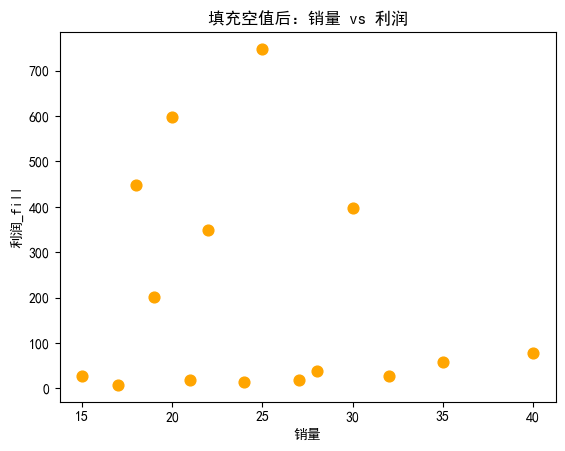

In [27]:
df_null.plot(
    kind='scatter',
    x='销量',
    y='利润_fill',
    title='填充空值后：销量 vs 利润',
    color='orange',
    s=60)
plt.show()